In [2]:
%cd ..
%ls

/home/suetin/Projects/Interview
app_logic.png  data/        models/     requirements.txt  train.py
checkpoints/   example.png  notebooks/  src/
config.yaml    main.py      README.md   tests/


In [3]:
import torch, os
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision.utils import make_grid

from src.dataset import ContrastiveDataset

In [4]:
# 
dataset = ContrastiveDataset(root_dir="data/flowers/", n_neg=3)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, drop_last=True)

In [5]:
batch = next(iter(loader))
orig = batch['anchor']
pos = batch['positive']
negs = batch['negatives']
labels = batch['class_idx']
orig.shape

torch.Size([32, 3, 224, 224])

In [6]:
pos.shape, negs.shape, labels

(torch.Size([32, 3, 224, 224]),
 torch.Size([32, 3, 3, 224, 224]),
 tensor([1, 4, 4, 3, 1, 2, 1, 0, 1, 2, 1, 1, 1, 1, 4, 1, 1, 3, 1, 2, 3, 2, 4, 3,
         0, 1, 2, 0, 2, 2, 4, 3]))

In [7]:
dataset.dataset.classes

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6726604..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1345534].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.2216995].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.5702832].


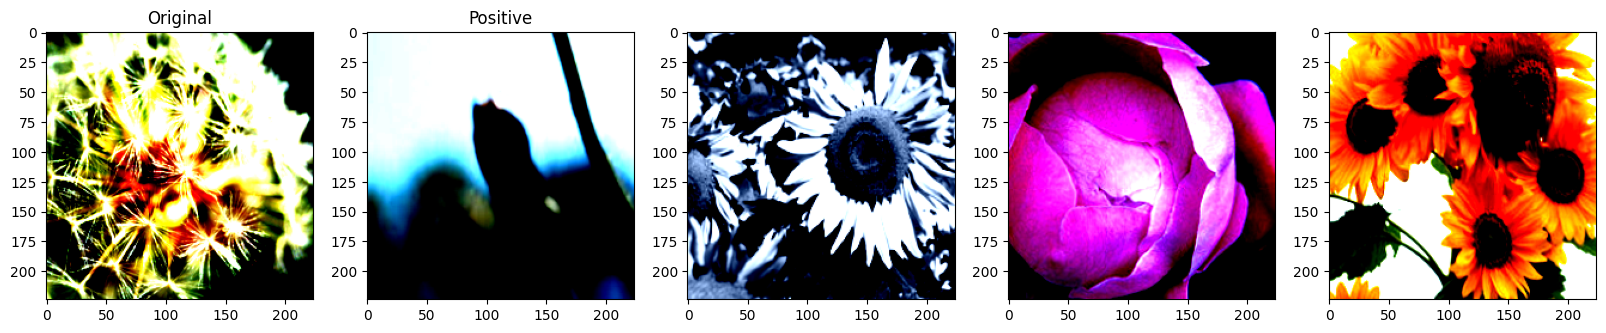

In [8]:
orig_img = orig[0].permute(1,2,0).numpy()
pos_img = pos[0].permute(1,2,0).numpy()
neg_1 = negs[0][0].permute(1,2,0).numpy()
neg_2 = negs[0][1].permute(1,2,0).numpy()
neg_3 = negs[0][2].permute(1,2,0).numpy()


plt.figure(figsize=(20,4))
plt.subplot(1,5,1)
plt.title("Original")
plt.imshow(orig_img)
plt.subplot(1,5,2)
plt.title("Positive")
plt.imshow(pos_img)
plt.subplot(1,5,3)
plt.imshow(neg_1)
plt.subplot(1,5,4)
plt.imshow(neg_2)
plt.subplot(1,5,5)    
plt.imshow(neg_3);

In [ ]:
import torch, yaml, os, pickle
from torch.utils.data import DataLoader
import faiss
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from src.model import ViTContrastive
from src.dataset import ContrastiveDataset
from src.steps import train_one_epoch, validate, inference_embeddings

In [20]:
# Load config
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = ViTContrastive()
model.load_state_dict(torch.load(cfg['model_path'], map_location=device))
model.to(device)
model.eval()

# Load validation dataset
val_dataset = ContrastiveDataset(cfg['data_path'], n_neg=3)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Get embeddings
embeddings, labels = inference_embeddings(model, val_loader, device)  # shape [N, D]
embeddings_np = embeddings.numpy().astype(np.float32)
with open("data/embeddings.pkl", "wb") as f:
    pickle.dump((embeddings_np, labels), f)
    print("Embeddings saved to data/embeddings.pkl")

/home/suetin/Projects/Interview/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/suetin/Projects/Interview/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Embedding: 100%|██████████| 68/68 [01:07<00:00,  1.00it/s]

Embeddings saved to data/embeddings.pkl


<PIL.Image.Image image mode=RGB size=224x224 at 0x792BF9338740>


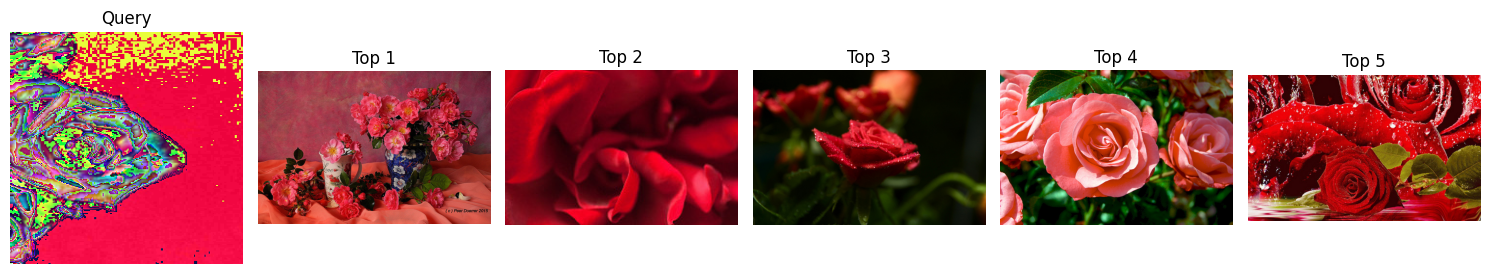

<PIL.Image.Image image mode=RGB size=224x224 at 0x792BF907E5D0>


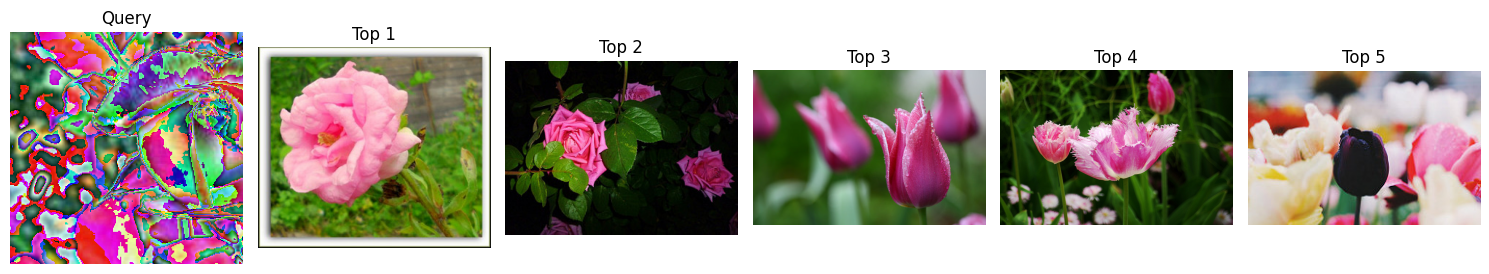

<PIL.Image.Image image mode=RGB size=224x224 at 0x792BF950B380>


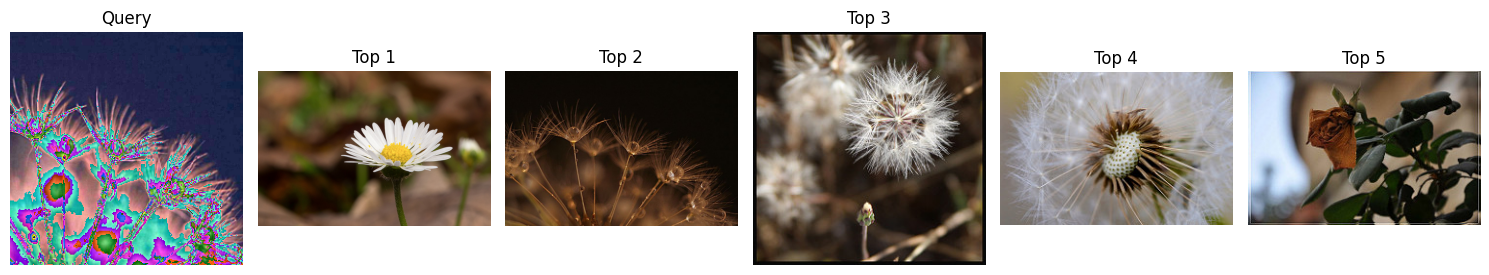

<PIL.Image.Image image mode=RGB size=224x224 at 0x792BE51E8A40>


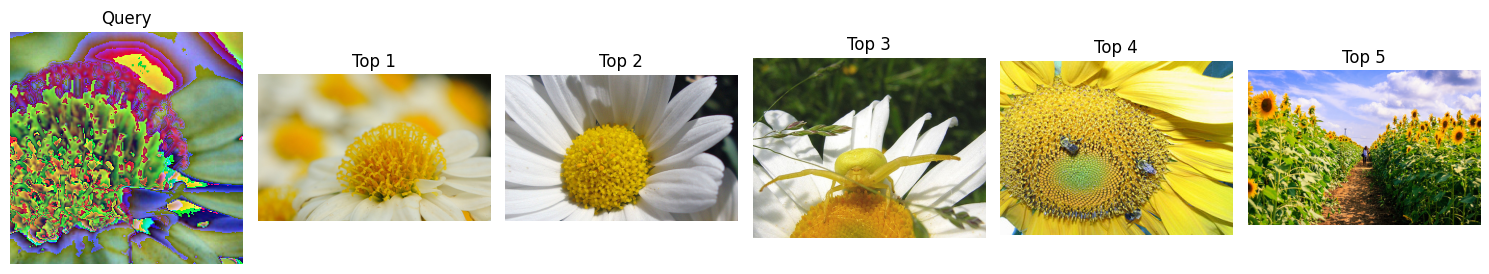

<PIL.Image.Image image mode=RGB size=224x224 at 0x792BE4CD1E80>


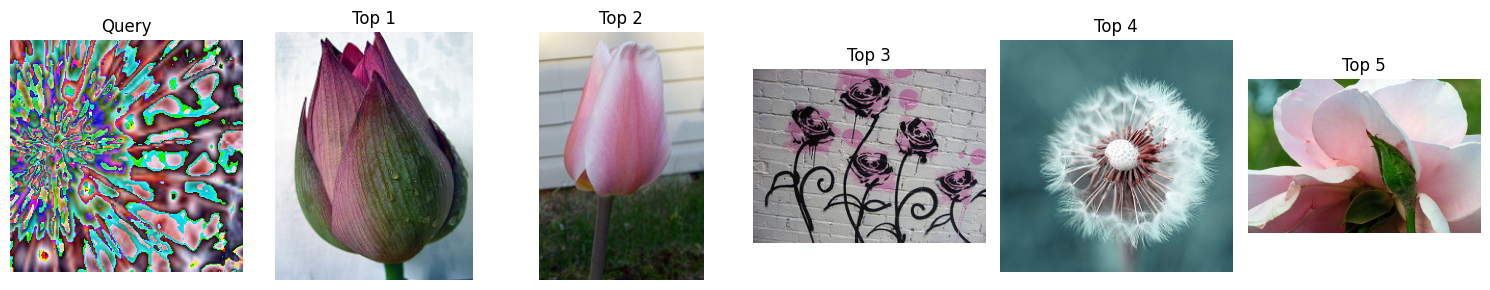

In [ ]:
# Build Faiss index
faiss.normalize_L2(embeddings_np)  # required for cosine similarity
index = faiss.IndexFlatIP(embeddings_np.shape[1])
index.add(embeddings_np)

# Visualize top-5 results for 5 random query images
transform = val_dataset.transform
samples = [val_dataset[i] for i in torch.randint(0, len(val_dataset), (5,))]

for i, sample in enumerate(samples):
    query_tensor = sample['anchor'].unsqueeze(0).to(device)
    query_emb = model(query_tensor)
    query_emb = torch.nn.functional.normalize(query_emb, dim=1)
    query_np = query_emb.detach().cpu().numpy().astype(np.float32)

    _, top5_indices = index.search(query_np, 5)

    image = sample['anchor']
    image = transforms.ToPILImage()(image)
    print(image)
    # Plot results
    plt.figure(figsize=(15, 3))
    plt.subplot(1, 6, 1)
    plt.imshow(transforms.ToPILImage()(sample['anchor']))
    plt.title("Query")
    plt.axis('off')

    for j, idx in enumerate(top5_indices[0]):
        img_path, _ = val_dataset.dataset.imgs[idx]
        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, 6, j + 2)
        plt.imshow(img)
        plt.title(f"Top {j+1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()